<a href="https://colab.research.google.com/github/FeDevPolis/QuantumXSchool/blob/main/Sessions1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install qiskit matplotlib -q


=== Qubit State Explorer ===
1. X Gate
2. Y Gate
3. Z Gate
4. H (Hadamard) Gate
5. RY Gate
6. ALL Gates (Show Everything)

Choose an option (1-6 or name): 6
Enter rotation angle theta for RY in radians (default pi/2): 90


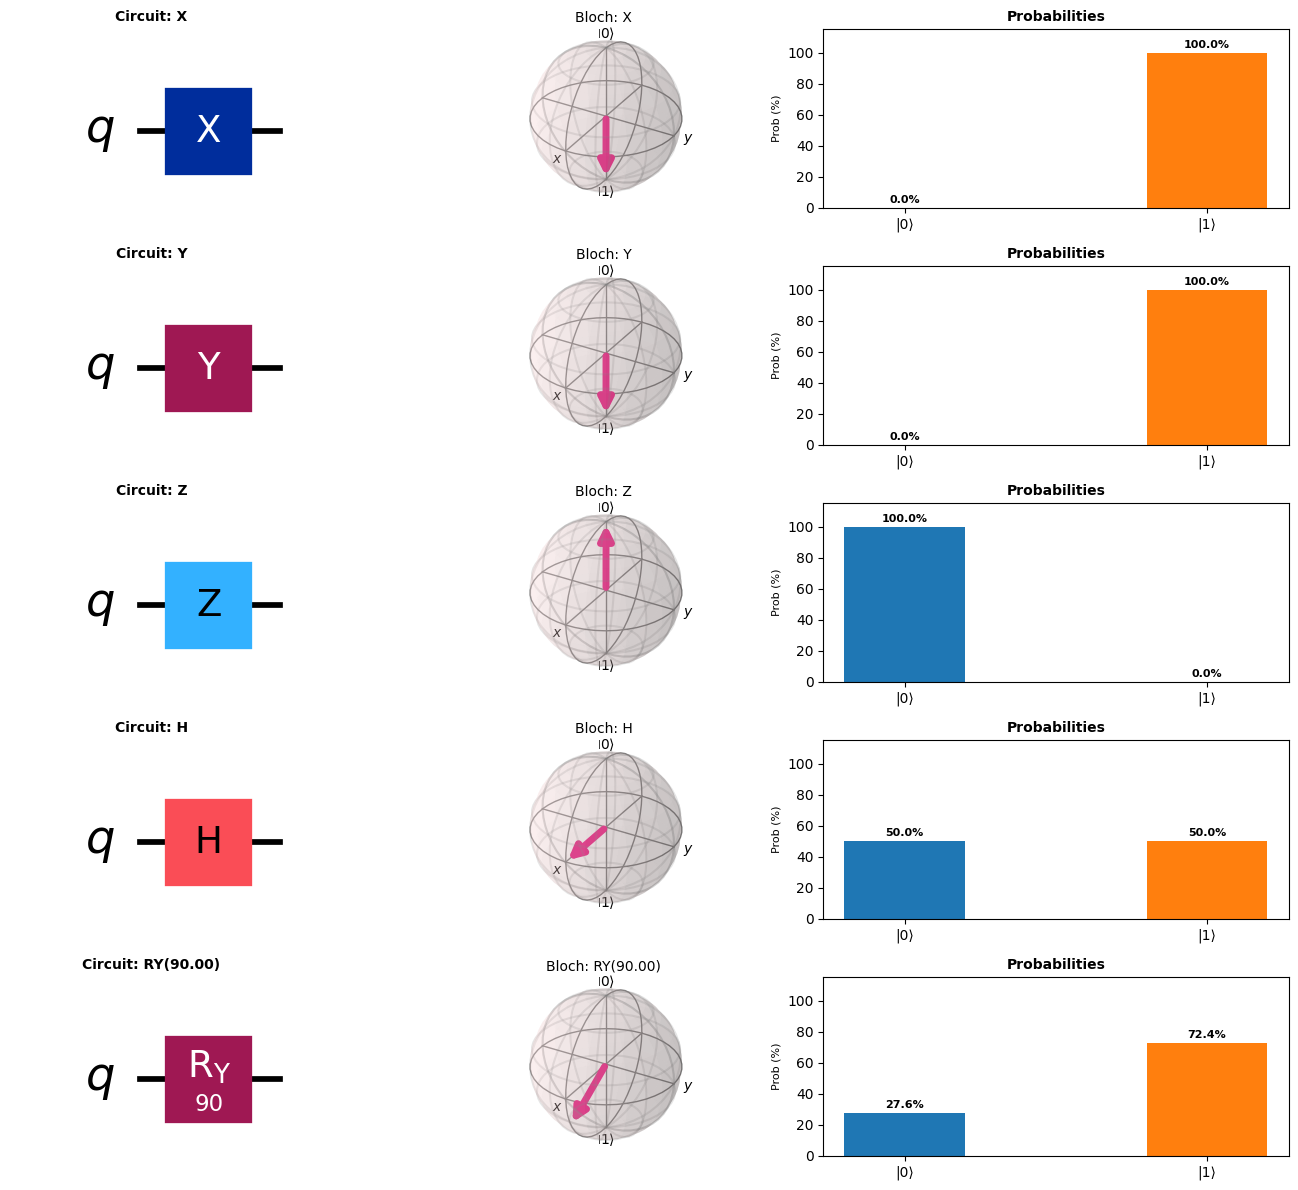

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import circuit_drawer, plot_bloch_vector

print("=== Qubit State Explorer ===")
print("1. X Gate")
print("2. Y Gate")
print("3. Z Gate")
print("4. H (Hadamard) Gate")
print("5. RY Gate")
print("6. ALL Gates (Show Everything)")

choice = input("\nChoose an option (1-6 or name): ").strip().upper()

gates_map = {
    "1": "X",
    "2": "Y",
    "3": "Z",
    "4": "H",
    "5": "RY",
    "6": "ALL",
    "X": "X",
    "Y": "Y",
    "Z": "Z",
    "H": "H",
    "RY": "RY",
    "ALL": "ALL",
}

selected = gates_map.get(choice, choice)


def process_gate(gate_name, theta_val=np.pi / 2):
    """Crea el circuito y calcula probabilidades y vector de Bloch."""
    qc = QuantumCircuit(1)
    if gate_name == "X":
        qc.x(0)
    elif gate_name == "Y":
        qc.y(0)
    elif gate_name == "Z":
        qc.z(0)
    elif gate_name == "H":
        qc.h(0)
    elif gate_name == "RY":
        qc.ry(theta_val, 0)

    state = Statevector.from_instruction(qc)
    prob_0 = abs(state[0]) ** 2
    prob_1 = abs(state[1]) ** 2

    # Coordenadas de Bloch
    x = 2 * (state[0].real * state[1].real + state[0].imag * state[1].imag)
    y = 2 * (state[0].imag * state[1].real - state[0].real * state[1].imag)
    z = abs(state[0]) ** 2 - abs(state[1]) ** 2

    return qc, prob_0, prob_1, [x, y, z]


def render_row(fig, row_idx, total_rows, gate_label, qc, prob_0, prob_1, bloch_vec):
    """Renderiza la fila de 3 paneles (Circuito, Bloch, Barras) para una compuerta."""
    base_idx = row_idx * 3

    # Panel 1: Circuito
    ax_circuit = fig.add_subplot(total_rows, 3, base_idx + 1)
    circuit_drawer(qc, output="mpl", ax=ax_circuit)
    ax_circuit.set_title(f"Circuit: {gate_label}", fontsize=10, fontweight="bold")

    # Panel 2: Esfera de Bloch
    ax_bloch = fig.add_subplot(total_rows, 3, base_idx + 2, projection="3d")
    plot_bloch_vector(bloch_vec, ax=ax_bloch, title=f"Bloch: {gate_label}")

    # Panel 3: Probabilidades
    ax_prob = fig.add_subplot(total_rows, 3, base_idx + 3)
    states = ["|0⟩", "|1⟩"]
    probabilities = [prob_0 * 100, prob_1 * 100]
    bars = ax_prob.bar(states, probabilities, color=["#1f77b4", "#ff7f0e"], width=0.4)
    ax_prob.set_ylim(0, 115)
    ax_prob.set_ylabel("Prob (%)", fontsize=8)
    ax_prob.set_title("Probabilities", fontsize=10, fontweight="bold")

    for bar in bars:
        yval = bar.get_height()
        ax_prob.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 2,
            f"{yval:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )


# --- LÓGICA PRINCIPAL ---
if selected == "ALL":
    try:
        theta = float(
            input("Enter rotation angle theta for RY in radians (default pi/2): ")
        )
    except ValueError:
        theta = np.pi / 2

    gates_to_show = ["X", "Y", "Z", "H", f"RY({theta:.2f})"]
    fig = plt.figure(figsize=(14, 12))
    fig.canvas.manager.set_window_title("Qubit State Explorer - All Gates")

    for idx, g in enumerate(["X", "Y", "Z", "H", "RY"]):
        label = f"RY({theta:.2f})" if g == "RY" else g
        qc, p0, p1, bloch = process_gate(g, theta)
        render_row(fig, idx, 5, label, qc, p0, p1, bloch)

else:
    theta = np.pi / 2
    if selected == "RY":
        try:
            theta = float(
                input(
                    "Enter rotation angle theta in radians (e.g., 1.57 or 3.14): "
                )
            )
        except ValueError:
            print("Invalid angle. Defaulting to pi/2 radians.")
            theta = np.pi / 2
        label = f"RY({theta:.2f})"
    elif selected in ["X", "Y", "Z", "H"]:
        label = selected
    else:
        print("Invalid option. Defaulting to X Gate.")
        selected = "X"
        label = "X"

    qc, p0, p1, bloch = process_gate(selected, theta)

    # Imprimir consola
    print(f"\n--- Quantum Circuit ({label}) ---")
    print(qc.draw("text"))
    print("\n--- Measurement Probabilities ---")
    print(f"P(|0⟩): {p0:.4f} ({p0 * 100:.1f}%)")
    print(f"P(|1⟩): {p1:.4f} ({p1 * 100:.1f}%)")

    fig = plt.figure(figsize=(14, 4.5))
    fig.canvas.manager.set_window_title("Qubit State Explorer")
    render_row(fig, 0, 1, label, qc, p0, p1, bloch)

plt.tight_layout()
plt.show()